# Mean estimates

Assume $x_t \sim P$ with $E_P[x_t] = \mu$ its expected value.

Let $\mu_T = \frac{1}{T} \sum_{t=1}^T x_t$ be the *empirical mean*.
Let us see how the mean converges as we get more data. In this case, let us consider $x_t \in \{0,1\}$ coming from a Bernoulli distribution with parameter $\theta$, so that
$$x_t \sim \textrm{Bernoulli}(\theta), \qquad \theta \in [0,1]$$
meaning that
$$\Pr(x_t = 1 \mid \theta) = \theta,
\qquad
\Pr(x_t = 0 \mid \theta) = 1 - \theta.$$

It is easy to see that $E_P[x_t \mid \theta] = \theta$, so in this case $\mu = \theta$.

In the following code, we use:
- `x[t]`: $x_t$
- `mu[t]`: $\mu_t$
- `n_data`: $T$
- `theta`: $\theta$
- `np.random.choice()` Bernoulli()

In [1]:

import numpy as np
n_data = 100000
theta = 0.7
# generate the random x
x = np.random.choice(2, size=n_data, p = [1 - theta, theta])
# calculate their mean (inefficient but..)
mu = np.cumsum(x)/range(1, 1+n_data)
# mu = [np.mean(x[:t])  for t in range(n_data)] # an inefficient way of doing the same thing



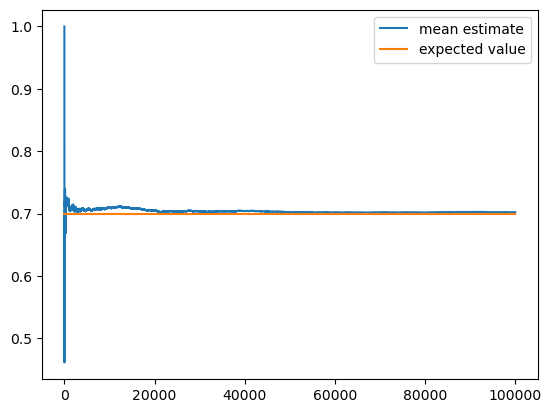

In [2]:
import matplotlib.pyplot as plt
plt.plot(mu)
plt.plot([0, n_data], [theta, theta])
plt.legend(["mean estimate", "expected value"])


# Home experimentation

1. What do you see? Does the line vary a lot?
2. What is the value at the beginning? Why is that?
3. What is the value at the end? Why?
4. What happens if you increase `n_data`?

# The mean as an unbiased estimator.

Even though the mean is never the same as the expected value, it is an unbiased estimator of $\theta$. This means that if we perform an experiment, the expected value of the mean is the same as the value of the thing we are trying to estimate, that is:

$$E_P[\mu_T] = \theta,$$

where the definition of $P$ is a distribution witincludes $\theta$

This can be proven easily, since due to linearity of expectations ($E_P[f + g] = E_P[f] + E_P[g]$) we have:

$E_P[\mu_T] = E_P[\sum_{t=1}^T x_t/T] = \sum_{t=1}^T E_P[x_t]/T =  \sum_{t=1}^T \theta / T$.

Let us now run the experiment $K$ times to obtain $x_{t,k}$. Each time we run the experiment, we average the mean value, to obtain an approximation of the expectated value of the mean.

In the code below,
- `n_experiments`: $K$

In [8]:
# generate the random x
n_experiments =1000
n_data = 100
# calculate their mean (inefficient but..)
mu = np.zeros(n_data)
for k in range(n_experiments):
    x = np.random.choice(2, size=n_data, p = [1 - theta, theta])
    mu += np.cumsum(x)/range(1, 1+n_data)
mu /= n_experiments



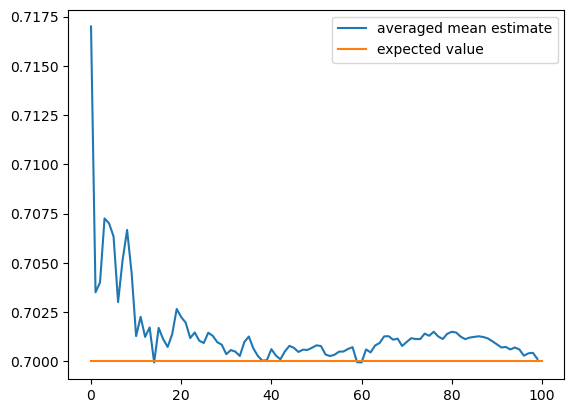

In [11]:
import matplotlib.pyplot as plt
plt.plot(mu)
plt.plot([0, n_data], [theta, theta])
plt.legend(["averaged mean estimate", "expected value"])


# Effect of the estimator

here we see that the average value of the estimator is very close to the actual estimand as we increase the number of experiments. 

1. Why is there still some variability everytime we run the experiment?
2. What is the value in the beginning vs the end?
   
To answer these questions, let us look at the variance of the estimator

In [40]:
# generate the random x
n_experiments =100
n_data = 100
# calculate their mean (inefficient but..)
mu = np.zeros([n_experiments, n_data])
x = np.random.choice(2, size=[n_experiments, n_data], p = [1 - theta, theta])
for k in range(n_experiments):
    mu[k] += np.cumsum(x[k])/range(1, 1+n_data)


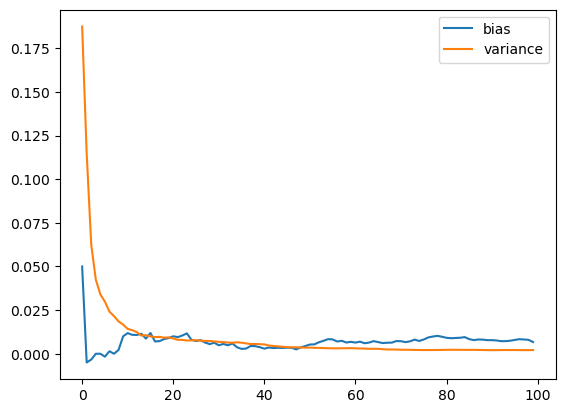

In [43]:
means= np.mean(mu,0) # get the mean over the experiments
vars = np.var(mu,0)
plt.plot(means-theta)
plt.plot(vars)
plt.legend(["bias", "variance"])

# Bias and variance of estimator.

Here we are plotting *estimates* of the bias and variance of the measn estimator. 

The bias of the estimator is the expected difference between the estimated and the true value, in this case:
$$\mathbb{B}(\mu_T) = E_P[\mu_t - \theta] = 0,$$
as we already proved that its expected value equals $\theta$. Hence, the estimator is unbiased.

Since the estimator is a **random variable** (!) it has a variance:
$$\mathbb{V}(\mu_T) = E_P[(\mu_t - E_P[\mu_t])^2].$$

It is possible to prove that the sample mean estimator has a variance that scales with rate $1/\sqrt{T}$. 
